# [LAB-10] 로지스틱회귀ㅣ01-1-단순로지스틱회귀(실습코드).ipynb

## #01. 준비작업 

### 1. 라이브러리 참조 

In [1]:
# 라이브러리 기본 참조
from jussam import load_data
from helpers import * 
from pandas import DataFrame
import numpy as np

# 로지스틱 회귀를 위한 참조 
from statsmodels.api import add_constant, Logit
from statsmodels.formula.api import logit as formula_logit 

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 가져오기 

In [2]:
origin =load_data('iris_bin')
origin.head()

📚 아이리스 데이터셋을 이진분류 예제용으로 종속변수의 종류를 2개로 변경한 데이터 (Kaggle의 데이터셋을 직접 수정함)

    field         description
--  ------------  ----------------------------
 0  Sepal_Length  꽃받침 길이
 1  Sepal_Width   꽃받침 너비
 2  Petal_Length  꽃잎 길이
 3  Petal_Width   꽃잎 너비
 4  Species       품종 (versicolor, virginica)



,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species
0,7.000,3.200,4.700,1.400,versicolor
1,6.400,3.200,4.500,1.500,versicolor
2,6.900,3.100,4.900,1.500,versicolor
3,5.500,2.300,4.000,1.300,versicolor
4,6.500,2.800,4.600,1.500,versicolor


### 3. 데이터 전처리 

In [3]:
df = origin[['Sepal_Length', 'Species']]
df = my_prep.labeling(df, columns=['Species'])
df.head()

Species (1종) : versicolor=0
Species (2종) : versicolor=0, virginica=1


,Sepal_Length,Species
0,7.000,0
1,6.400,0
2,6.900,0
3,5.500,0
4,6.500,0


## #02. 탐색적 데이터 분석 

### 1. 종속변수의 분포 확인 
두 범주의 빈도가 비슷한지(클래스 균형) 확인한다 \
한쪽으로 심하게 치우쳐 있으면 정확도가 높아 보여도 실제로는 쓸모없는 모형이 될 수 있다. 

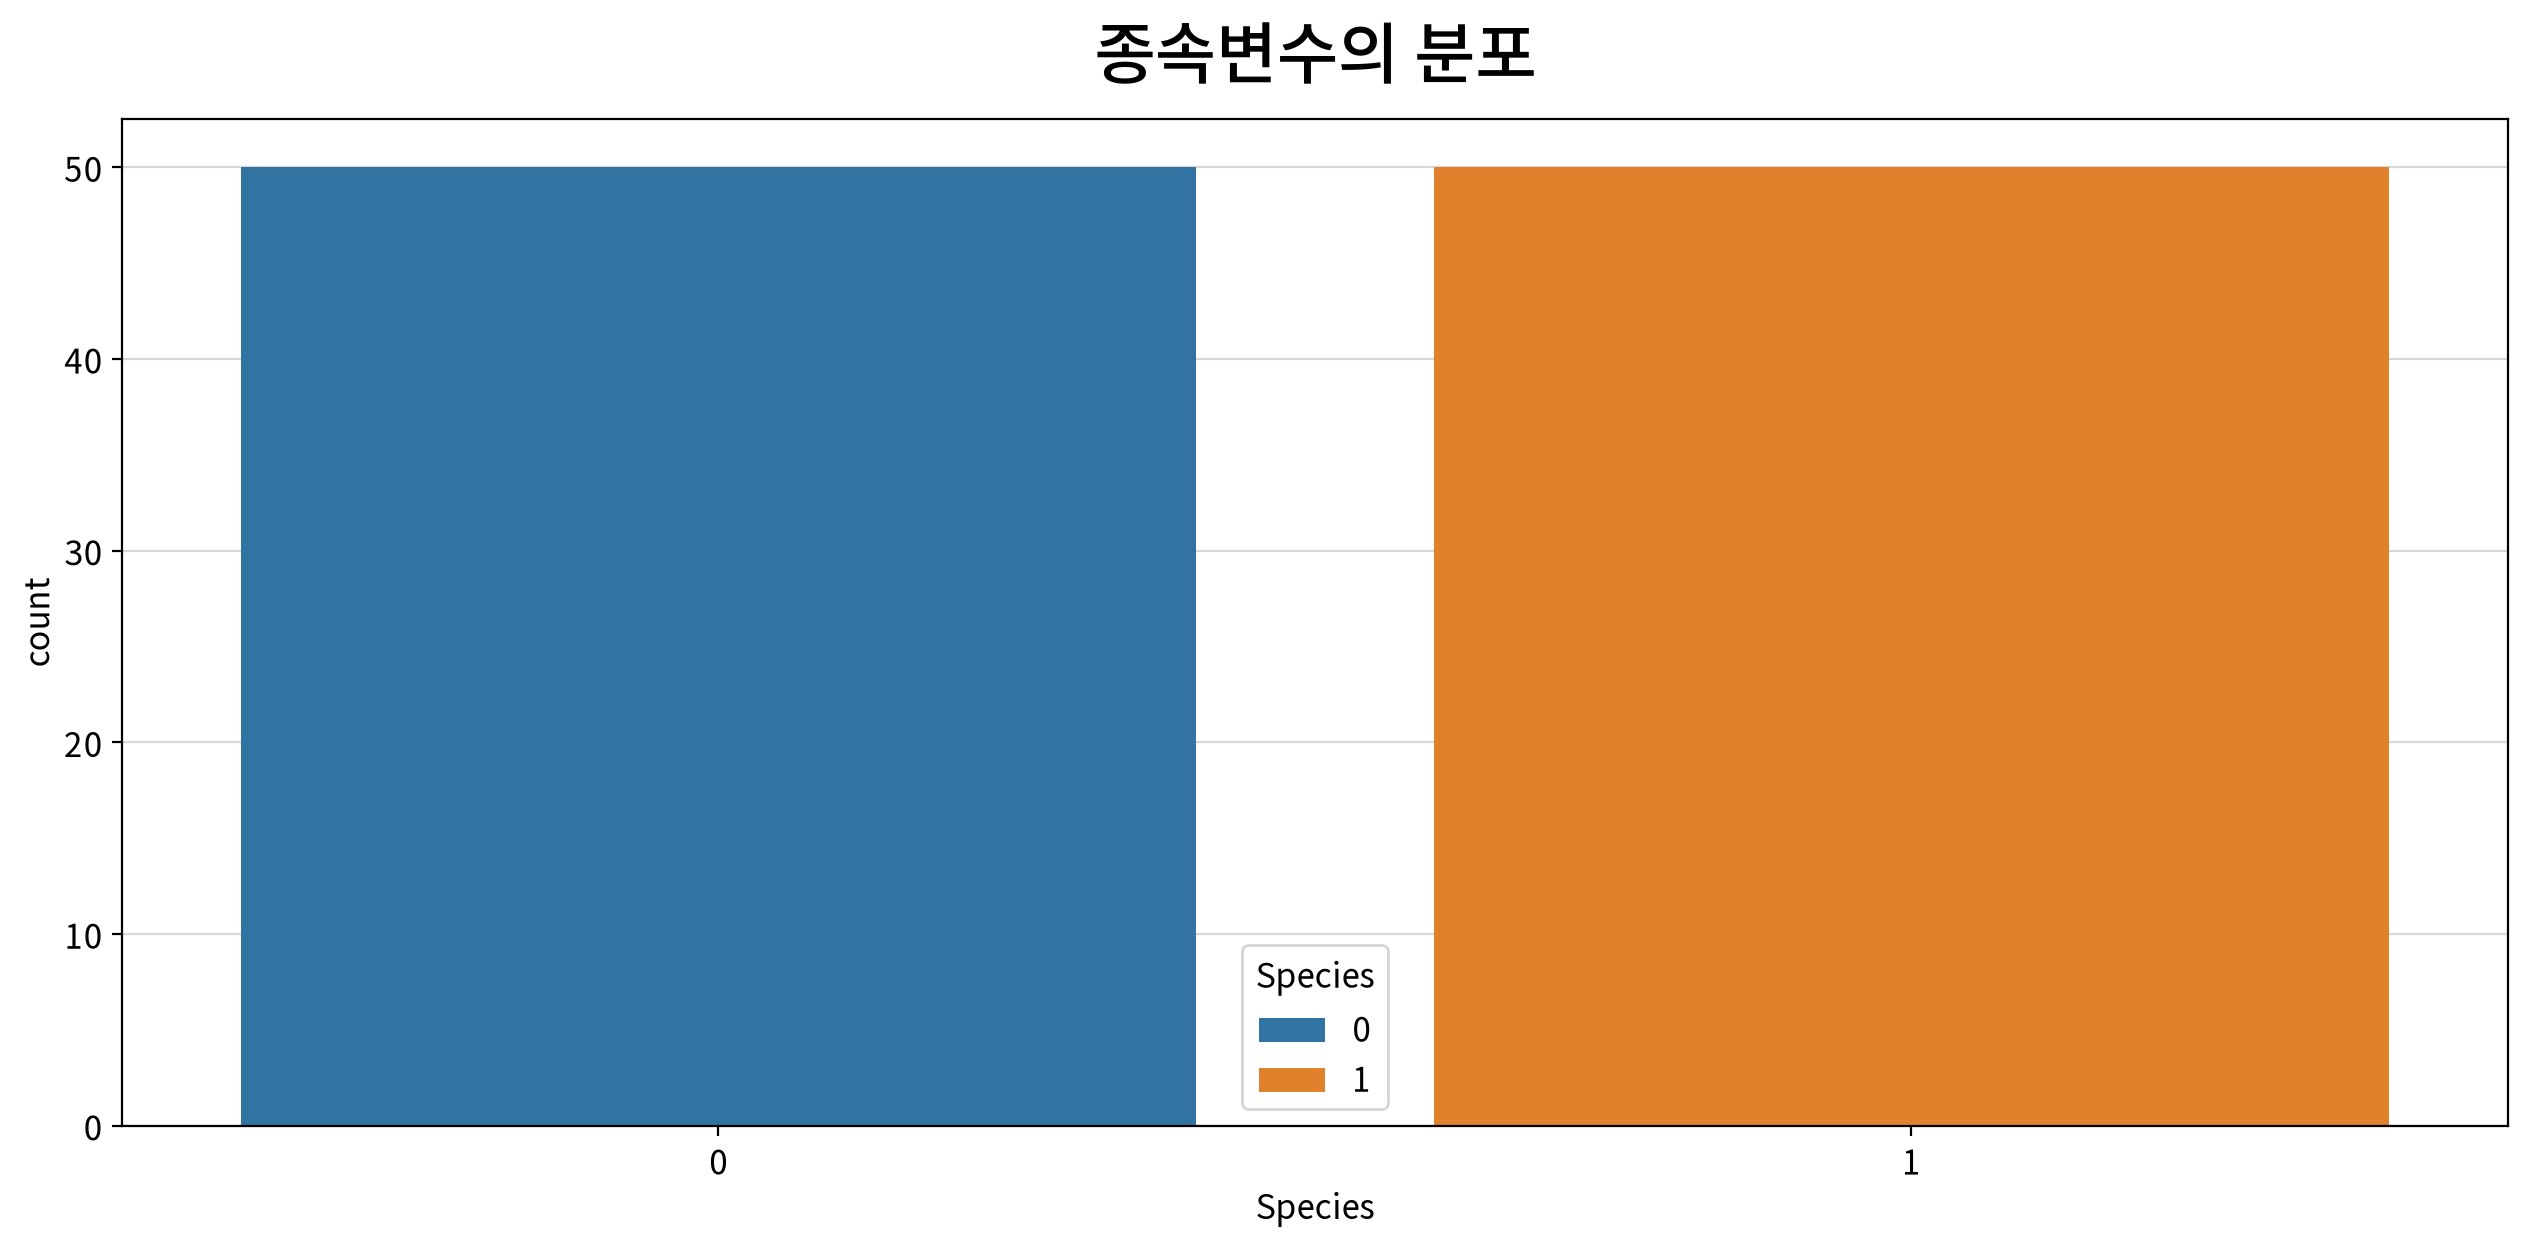

In [4]:
my_plot.countplot(df, x='Species', hue='Species', 
                  title='종속변수의 분포') 

### 2. 집단별 독립변수의 분포 비교 
품종에 따라 꽃받침 길이(Sepal_Length)의 분포가 다른지 확인한다. \
분포가 다를 수록 좋은 독립변수이다. 

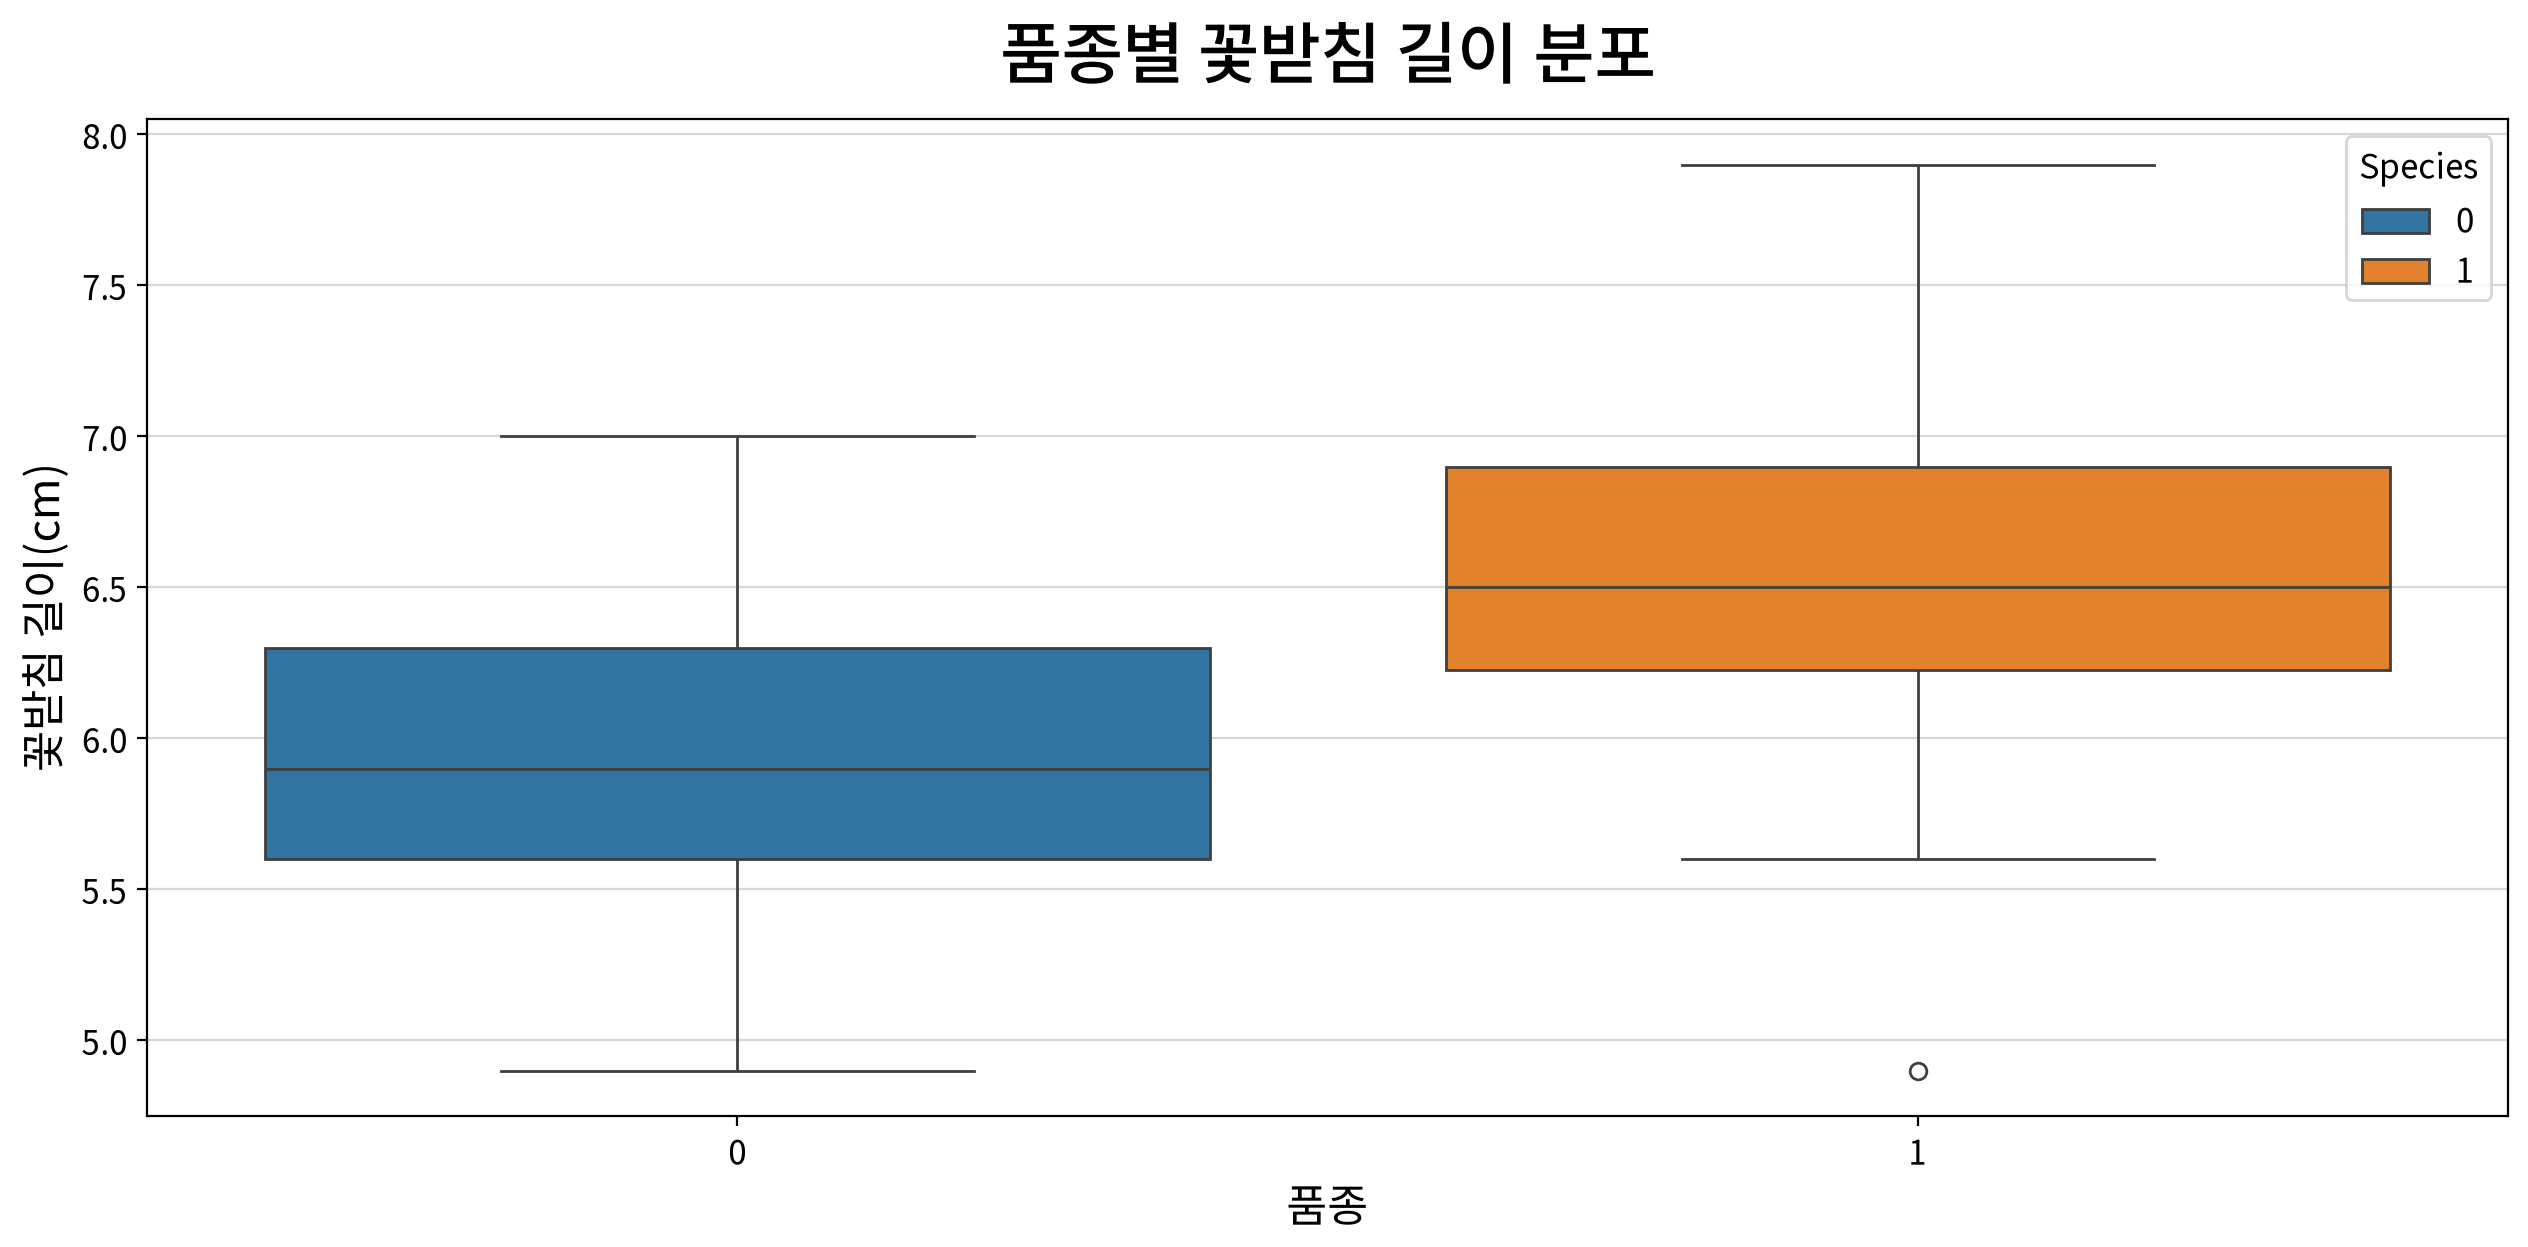

In [5]:
my_plot.boxplot(df, x='Species', y='Sepal_Length', hue='Species', 
                title='품종별 꽃받침 길이 분포', xlabel='품종', 
                ylabel='꽃받침 길이(cm)')

## #03. 로지스틱 회귀의 이해 

### 1. 단순선형회귀로 접근 

In [6]:
ols_fit = my_ols.auto_ols(df, y='Species', report=True, test=False)

#### ▶︎ 모형 적합도

,종속변수,독립변수,B,표준오차,베타,t,유의확률,공차,VIF
0,Species,Sepal_Length,0.375,0.067,0.494,5.629,0.000,1.000,1.000


**Note. n = 100. F(1, 98) = 31.69, p < 0.001, R² = 0.244, Adj.R² = 0.237, Durbin-Watson = 0.535**

Species를 종속변수로, Sepal_Length(을)를 독립변수로한 단순선형회귀분석 결과, 모형은 통계적으로 유의하였다.

> F(1, 98) = 31.69, p < 0.001, R² = 0.244.

즉, Sepal_Length는 Species의 약 24.43%를 설명하는 것으로 나타났다.

### 2. 단순선형회귀의 예측값 생성 

In [7]:
# 임의의 꽃받침 길이(4~9)에 대한 직선의 예측값 30개 
np.random.seed(1234) # 실행할 때마다 같은 결과가 나오도록 고정 
sample = DataFrame({'Sepal_Length': [np.random.uniform(4, 9) for _ in range(30)]})  
sample['예측값'] = ols_fit.predict(add_constant(sample))
sample.head()

,Sepal_Length,예측값
0,4.958,0.011
1,7.111,0.818
2,6.189,0.473
3,7.927,1.124
4,7.900,1.114


### 3. 실제 데이터와 예측 결과 시각화 

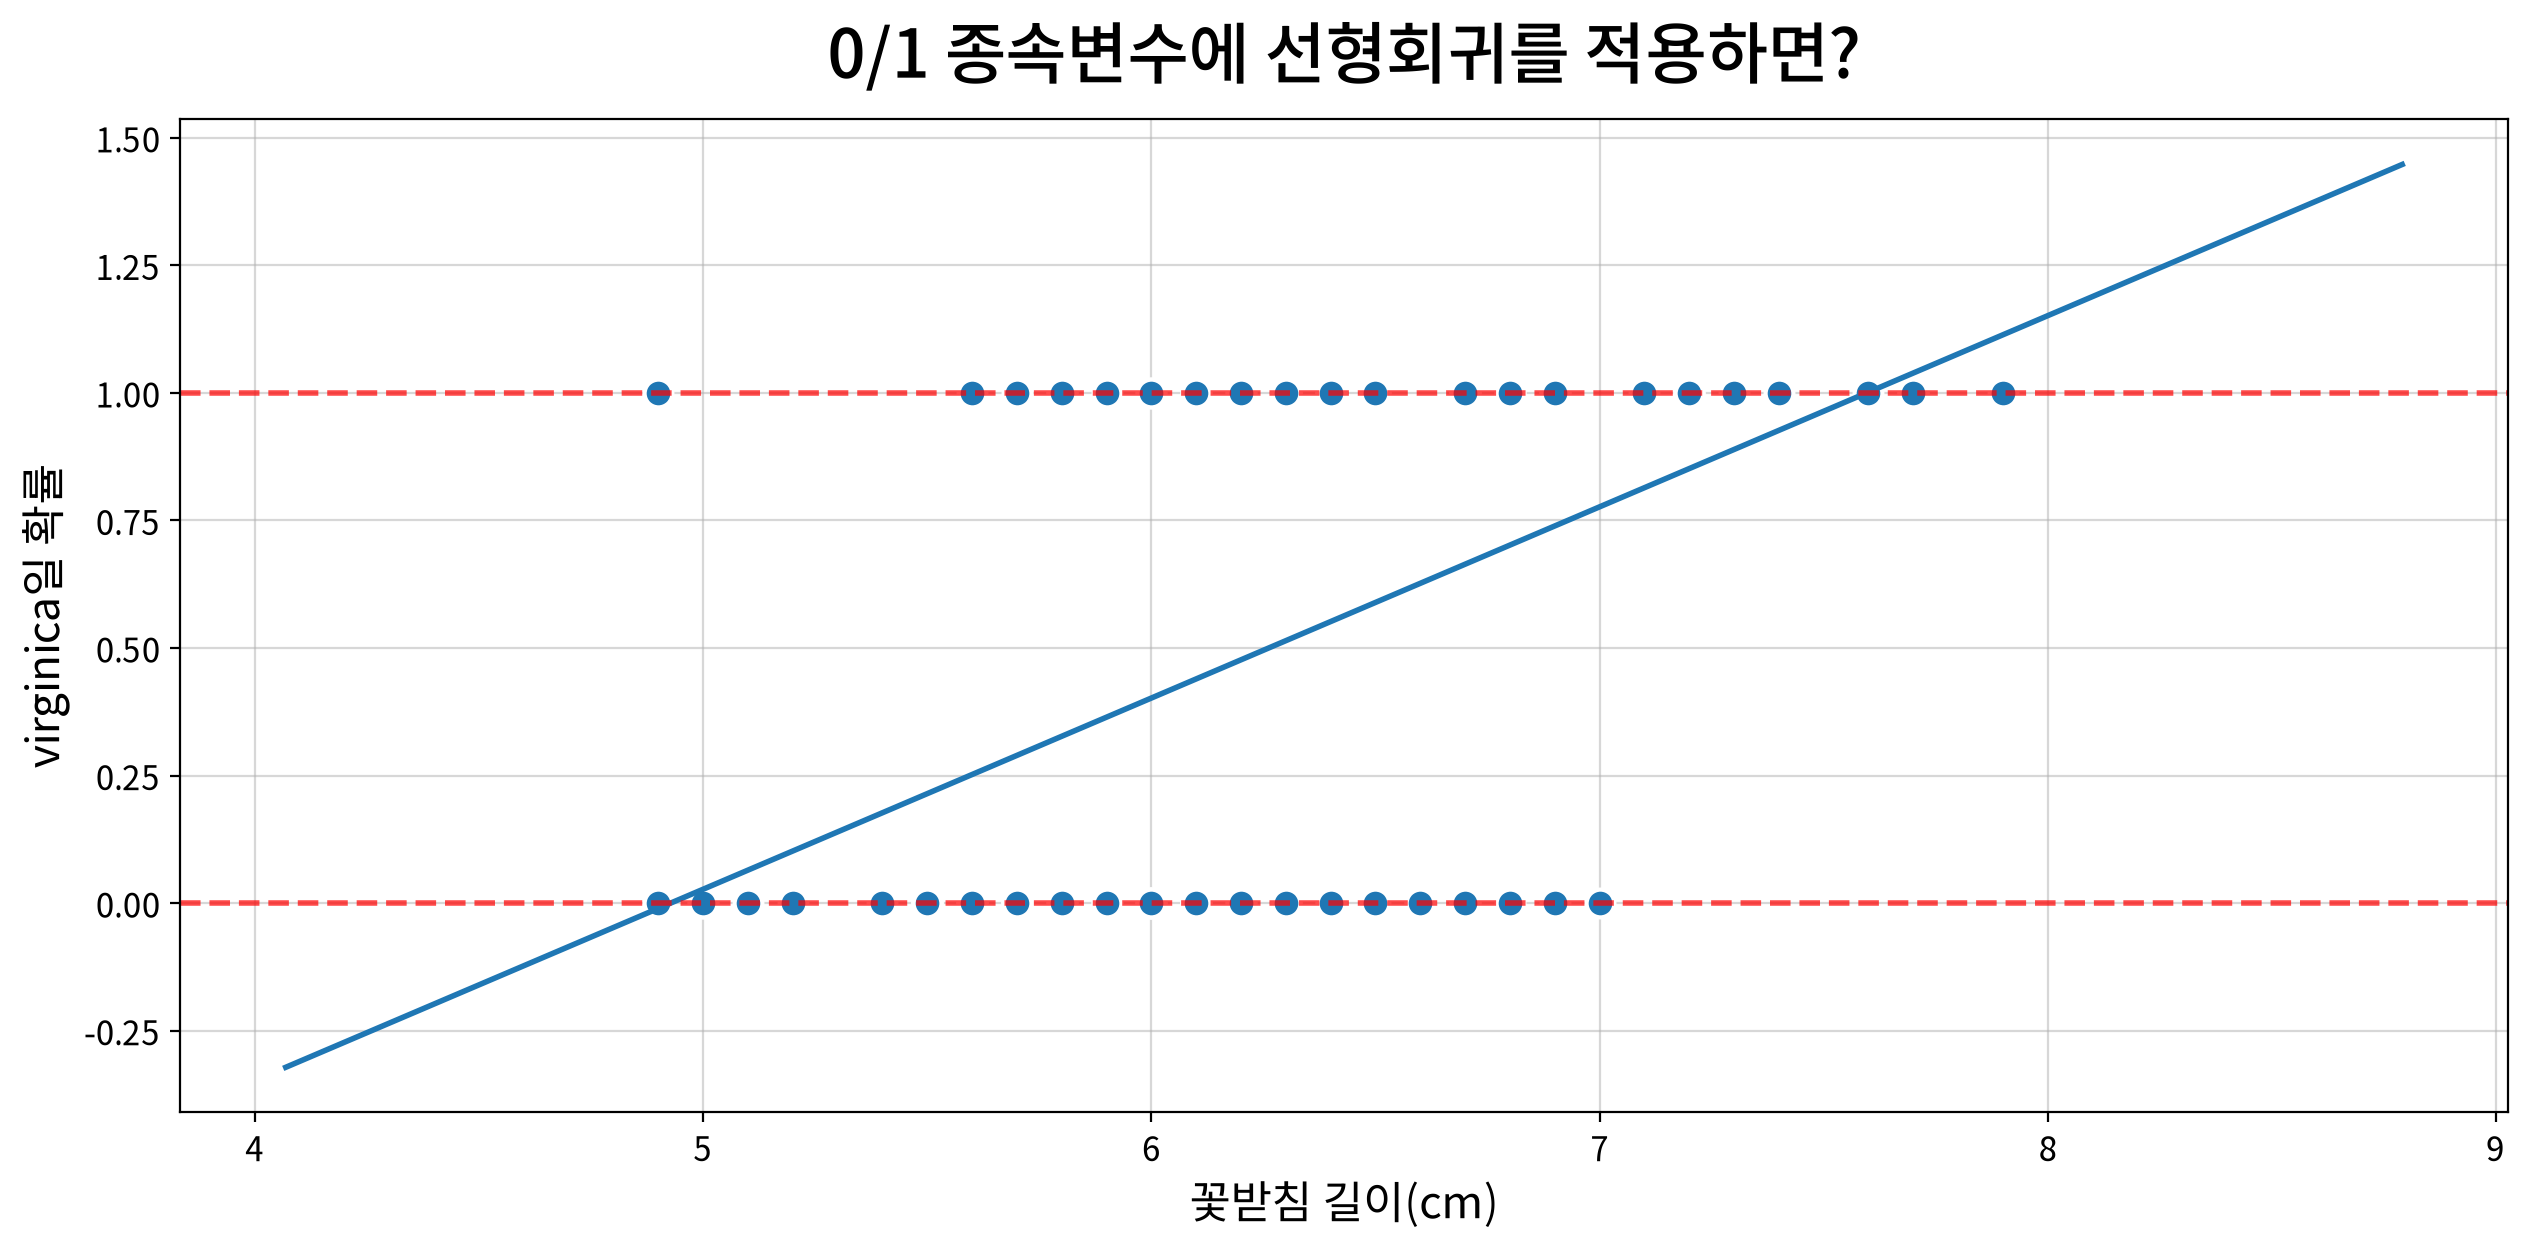

In [8]:
# 시각화 : 실제 관측치(0/1) + 선형회귀 직선 
fig, ax = my_plot.init(title='0/1 종속변수에 선형회귀를 적용하면?', 
                       xlabel='꽃받침 길이(cm)', ylabel='virginica일 확률')

# 실제 관측치는 0 또는 1, 두개의 높이에만 찍힌다.
my_plot.scatterplot(df, x='Sepal_Length', y='Species', ax=ax)

# 선형회귀가 찾아낸 직선 
my_plot.lineplot(sample, x='Sepal_Length', y='예측값', ax=ax)

# 확률이 존재할 수 있는 범위(0~1)
ax.axhline(y=1, color='red', linestyle='--', alpha=0.7)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.7)

my_plot.show()

### 4. 선형회귀의 예측값을 시그모이드에 통과 시키기 
앞에서 만든 직선예측값을 그대로 σ(z)에 넣어본다.\
    확률로 볼 수 없었던 값들이 0과 1사이로 눌러 담기는지 확인한다. 

In [9]:
# σ

In [10]:
sample['σ(z)'] = 1/(1+np.exp(-sample['예측값']))
sample['result'] = sample['σ(z)'].round()
sample.head()

,Sepal_Length,예측값,σ(z),result
0,4.958,0.011,0.503,1.000
1,7.111,0.818,0.694,1.000
2,6.189,0.473,0.616,1.000
3,7.927,1.124,0.755,1.000
4,7.900,1.114,0.753,1.000


### 5. 시그모이드 적용 결과 시각화 

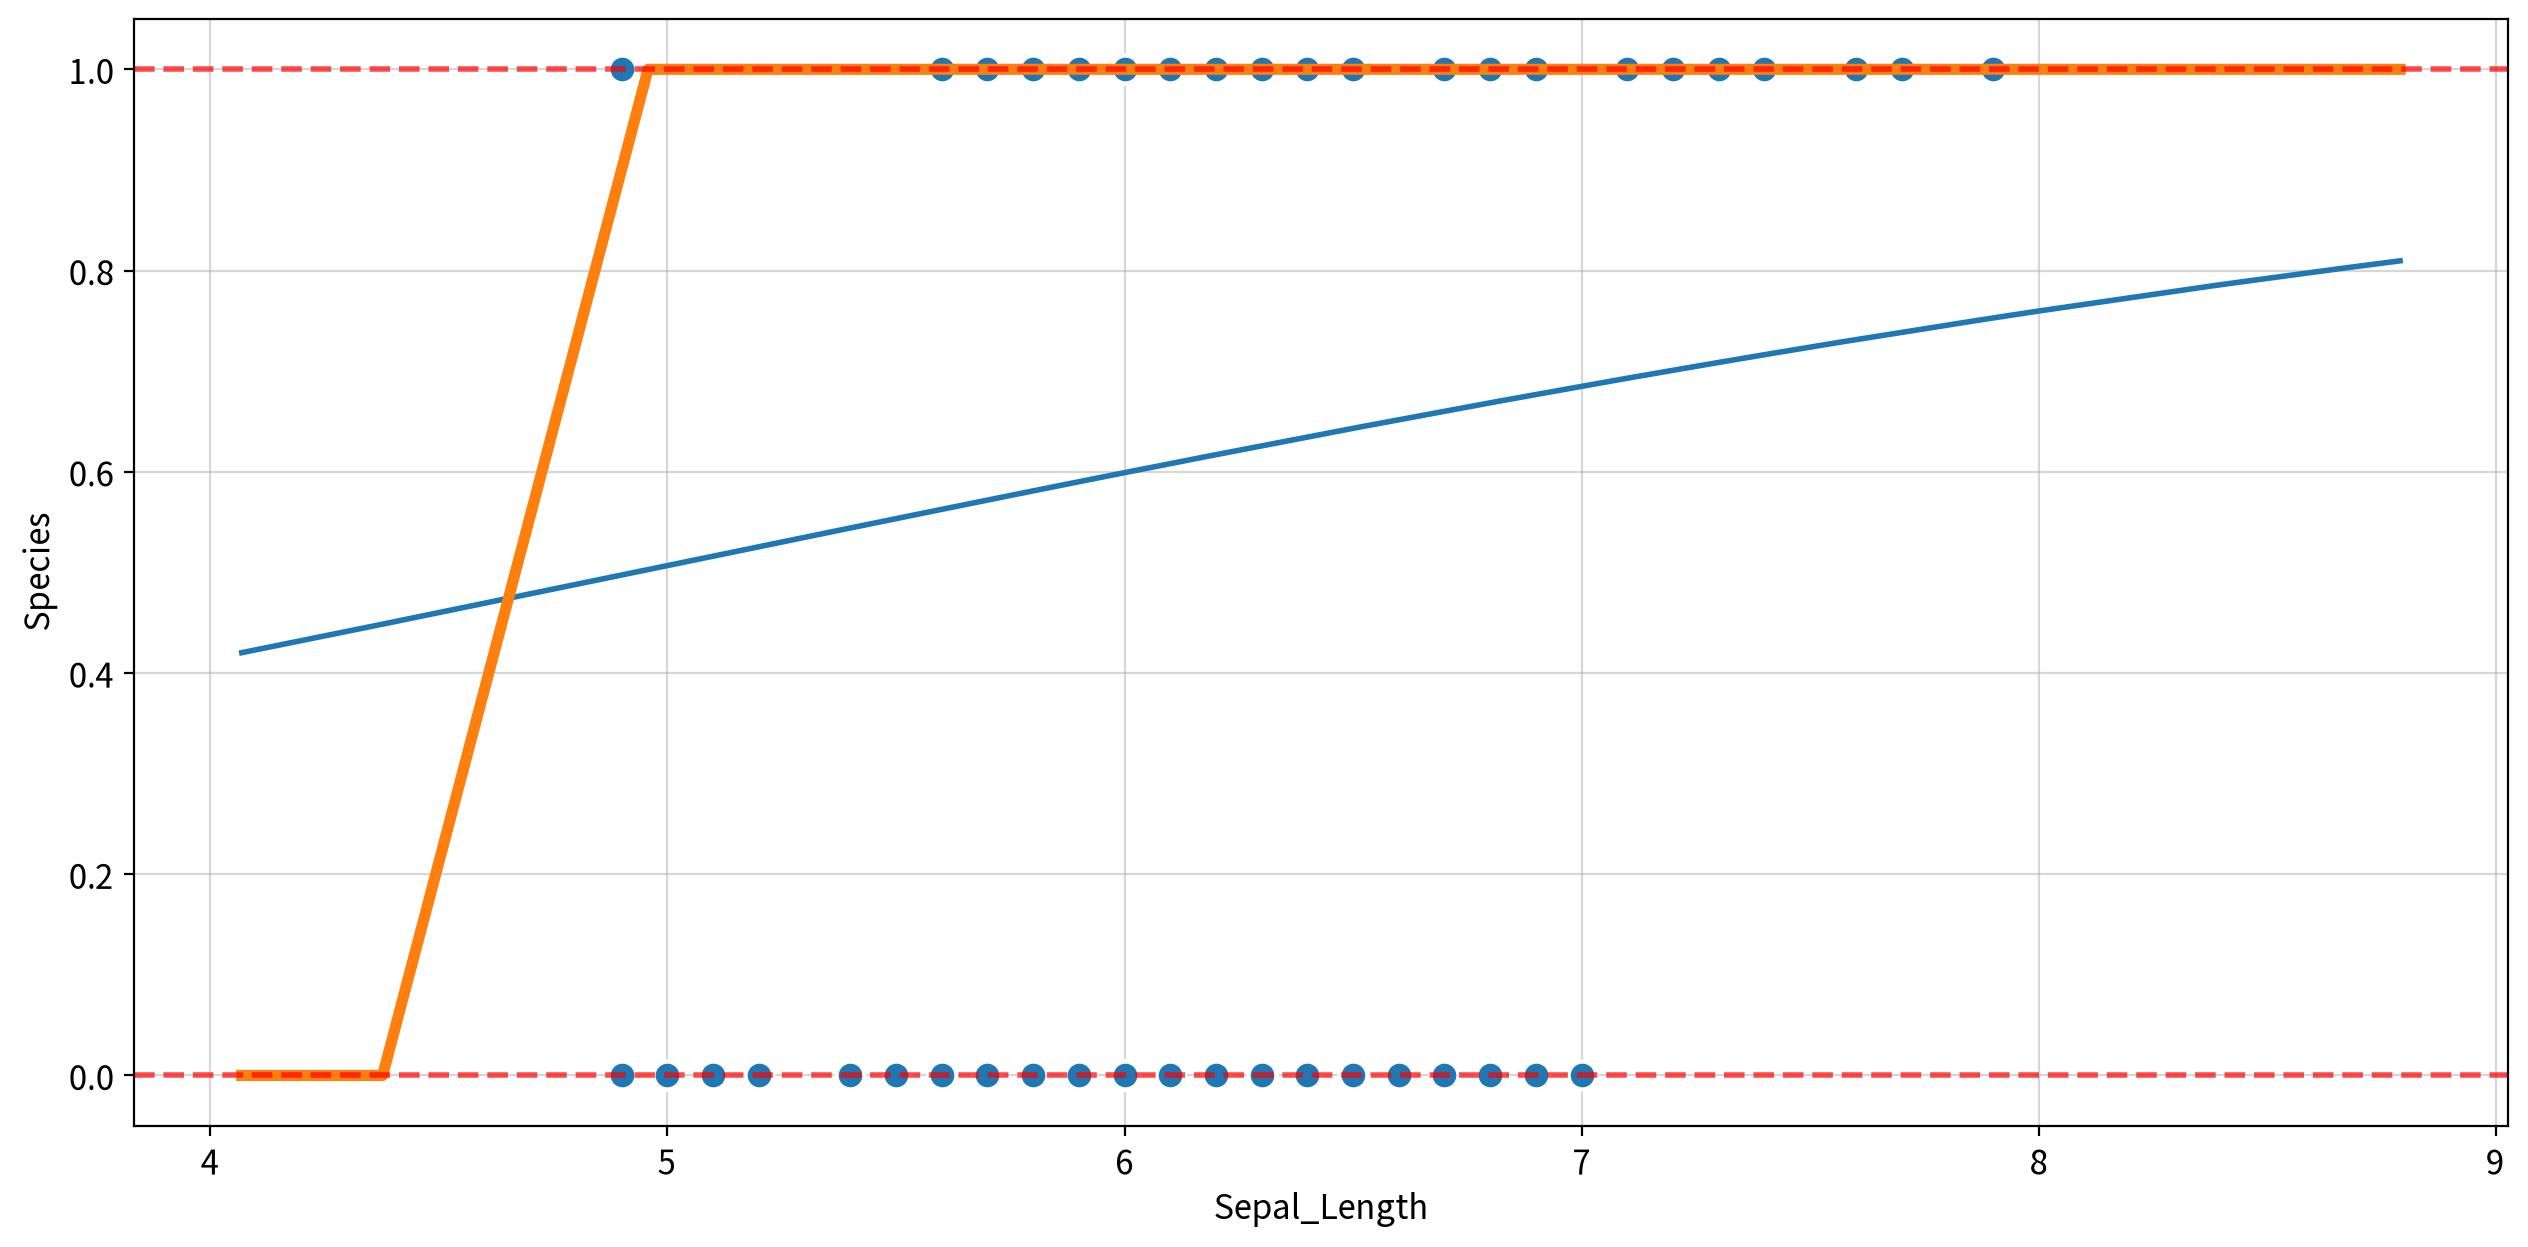

In [11]:
# 시각화 : 실제 관측치(0/1) + 시그모이드를 통과시킨 확률 + 임계값 적용 결과 
fit, ax = my_plot.init()

# 실제 관측치는 0 또는 1, 두개의 높이에만 찍힌다.
my_plot.scatterplot(df, x='Sepal_Length', y='Species', ax=ax)

# 직선의 예측값을 시그모이드에 통과시킨 확률 -> 0과 1사이에 머무른다.
my_plot.lineplot(sample, x='Sepal_Length', y='σ(z)', ax=ax)

# 확률은 반올림 (임계값 0.5)한 최종 분류 결과 
my_plot.lineplot(sample, x='Sepal_Length', y='result', linewidth=4, ax=ax)

# 확률이 존재할 수 있는 범위(0~1)
ax.axhline(y=1, color='red', linestyle='--', alpha=0.7)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.7)

my_plot.show()

## #04. 행렬 기반 방식의 단순로지스틱 회귀 

### 1. 독립변수 행렬 준비 
독립변수는 2차원 형태(DataFrame)으로 준비한다.

In [12]:
x = df[["Sepal_Length"]]
x.head()

,Sepal_Length
0,7.000
1,6.400
2,6.900
3,5.500
4,6.500


### 2. 종속변수 준비 
종속변수는 Series 객체 형태로 준비한다. \
반드시 0과 1로 인코딩 되어 있어야 한다. (앞에서 라벨링을 수행한 이유)

In [13]:
y = df["Species"]
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Species, dtype: int64

### 3. 상수항 추가 
시그모이드 안에 들어가는 식이 z = ax+b 형태이므로, \
b역할을 하기 위한 상수항을 추가해야 한다.\
상수항이 없다면 절편이 0으로 고정된 잘못된 모델이 만들어질 수 있다. 

In [14]:
x_input = add_constant(x)
x_input.head()

,const,Sepal_Length
0,1.000,7.000
1,1.000,6.400
2,1.000,6.900
3,1.000,5.500
4,1.000,6.500


### 4. 로지스틱 회귀 분석 수행 

In [15]:
# Logit 모델 객체 생성 
# -> 이 단계에서는 아직 학습(fit)되지 않은 '모형의 틀'만 만들어짐 
model = Logit(y, x_input)

# 모델 적합(Fit)
# -> 최대우도추정(MLE)을 반복계산하여 회귀계수(베타)를 추정한다. 
fit = model.fit()

# 적합된 모델 객체의 분석 결과 확인 
print(fit.summary())

Optimization terminated successfully.
         Current function value: 0.552733
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                Species   No. Observations:                  100
Model:                          Logit   Df Residuals:                       98
Method:                           MLE   Df Model:                            1
Date:                Thu, 30 Jul 2026   Pseudo R-squ.:                  0.2026
Time:                        12:47:51   Log-Likelihood:                -55.273
converged:                       True   LL-Null:                       -69.315
Covariance Type:            nonrobust   LLR p-value:                 1.162e-07
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -12.5708      2.907     -4.325      0.000     -18.268      -6.873
Sepal_Length     2.0129

### 5. formula API 방식의 로지스틱 회귀 

단순로지스틱 회귀 구현 \
종속변수 ~ 독립변수 형태의 수식을 문자열로 전달한다. \
상수항을 자동 처리하므로 직접 추가하지 않아도 된다. 

In [16]:
# 학습 모델 객체 생성 
model = formula_logit("Species ~ Sepal_Length", data=df)
fit2 = model.fit() # 모델적합 
print(fit2.summary()) # 분석결과 확인 

Optimization terminated successfully.
         Current function value: 0.552733
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                Species   No. Observations:                  100
Model:                          Logit   Df Residuals:                       98
Method:                           MLE   Df Model:                            1
Date:                Thu, 30 Jul 2026   Pseudo R-squ.:                  0.2026
Time:                        12:47:51   Log-Likelihood:                -55.273
converged:                       True   LL-Null:                       -69.315
Covariance Type:            nonrobust   LLR p-value:                 1.162e-07
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      -12.5708      2.907     -4.325      0.000     -18.268      -6.873
Sepal_Length     2.0129

행렬기반 방식과 완전히 동일한 결과가 나온다.
상수항을 누가 추가하느냐의 차이일 뿐이다. 

## #06. 실제 데이터와 모형의 예측값 비교 

### 1. 예측 확률 생성 
분석 모형에 x에 해당하는 Sepal_Length를 넣으면, virginica일 확률이 계산된다. 

In [17]:
# 예측값을 생성하기 위해서는 상수항이 추가된 데이터를 사용해야 한다. 
predict_input = add_constant(df[["Sepal_Length"]])

new_df = df[["Sepal_Length", "Species"]].copy()

# virginica일 확률 
new_df['proba'] = fit.predict(predict_input)    

new_df.head()

,Sepal_Length,Species,proba
0,7.000,0,0.820
1,6.400,0,0.577
2,6.900,0,0.789
3,5.500,0,0.182
4,6.500,0,0.626


### 2. 확률을 범주로 변환 (임계값 적용)
로지스틱회귀의 출력은 확률이므로, 최종적으로 0과 1중 하나로 분류하려면 기준이 필요하다 

In [18]:
threshold = 0.5

# 확률이 임계값을 넘으면 1(virginica), 넘지 못하면 0(virsicolor)
new_df['pred'] = (new_df['proba'] > threshold).astype(int)

new_df.head()

,Sepal_Length,Species,proba,pred
0,7.000,0,0.820,1
1,6.400,0,0.577,1
2,6.900,0,0.789,1
3,5.500,0,0.182,0
4,6.500,0,0.626,1


### 3. 분류 경계 확인 
확률이 정확히 0.5가 되는 지점은 시그모이드의 정의상 z = 0인 곳이다.\ 
즉, ax+b=0 을 만족하는 x가 0과 1을 가르는 분류 경계가 된다. 

In [19]:
a = fit.params['Sepal_Length'] # 기울기 
b = fit.params['const'] # 절편 

boundary = -b/a

print(f"기울기 a = {a:.4f}, 절편 b = {b:.4f}")
print(f"분류경계 : 꽃받침 길이 {boundary:.2f}cm")


기울기 a = 2.0129, 절편 b = -12.5708
분류경계 : 꽃받침 길이 6.25cm


꽃받침 길이가 6.25cm 보다 길면 virginica(1), 짧으면 versicolor(0)로 분류된다. 
선형회귀에서 회귀직선이 "예측선"이었다면, 로지스티회귀에서는 이 지점이 판단의 기준선이 된다. 

### 4. 시각화 비교 

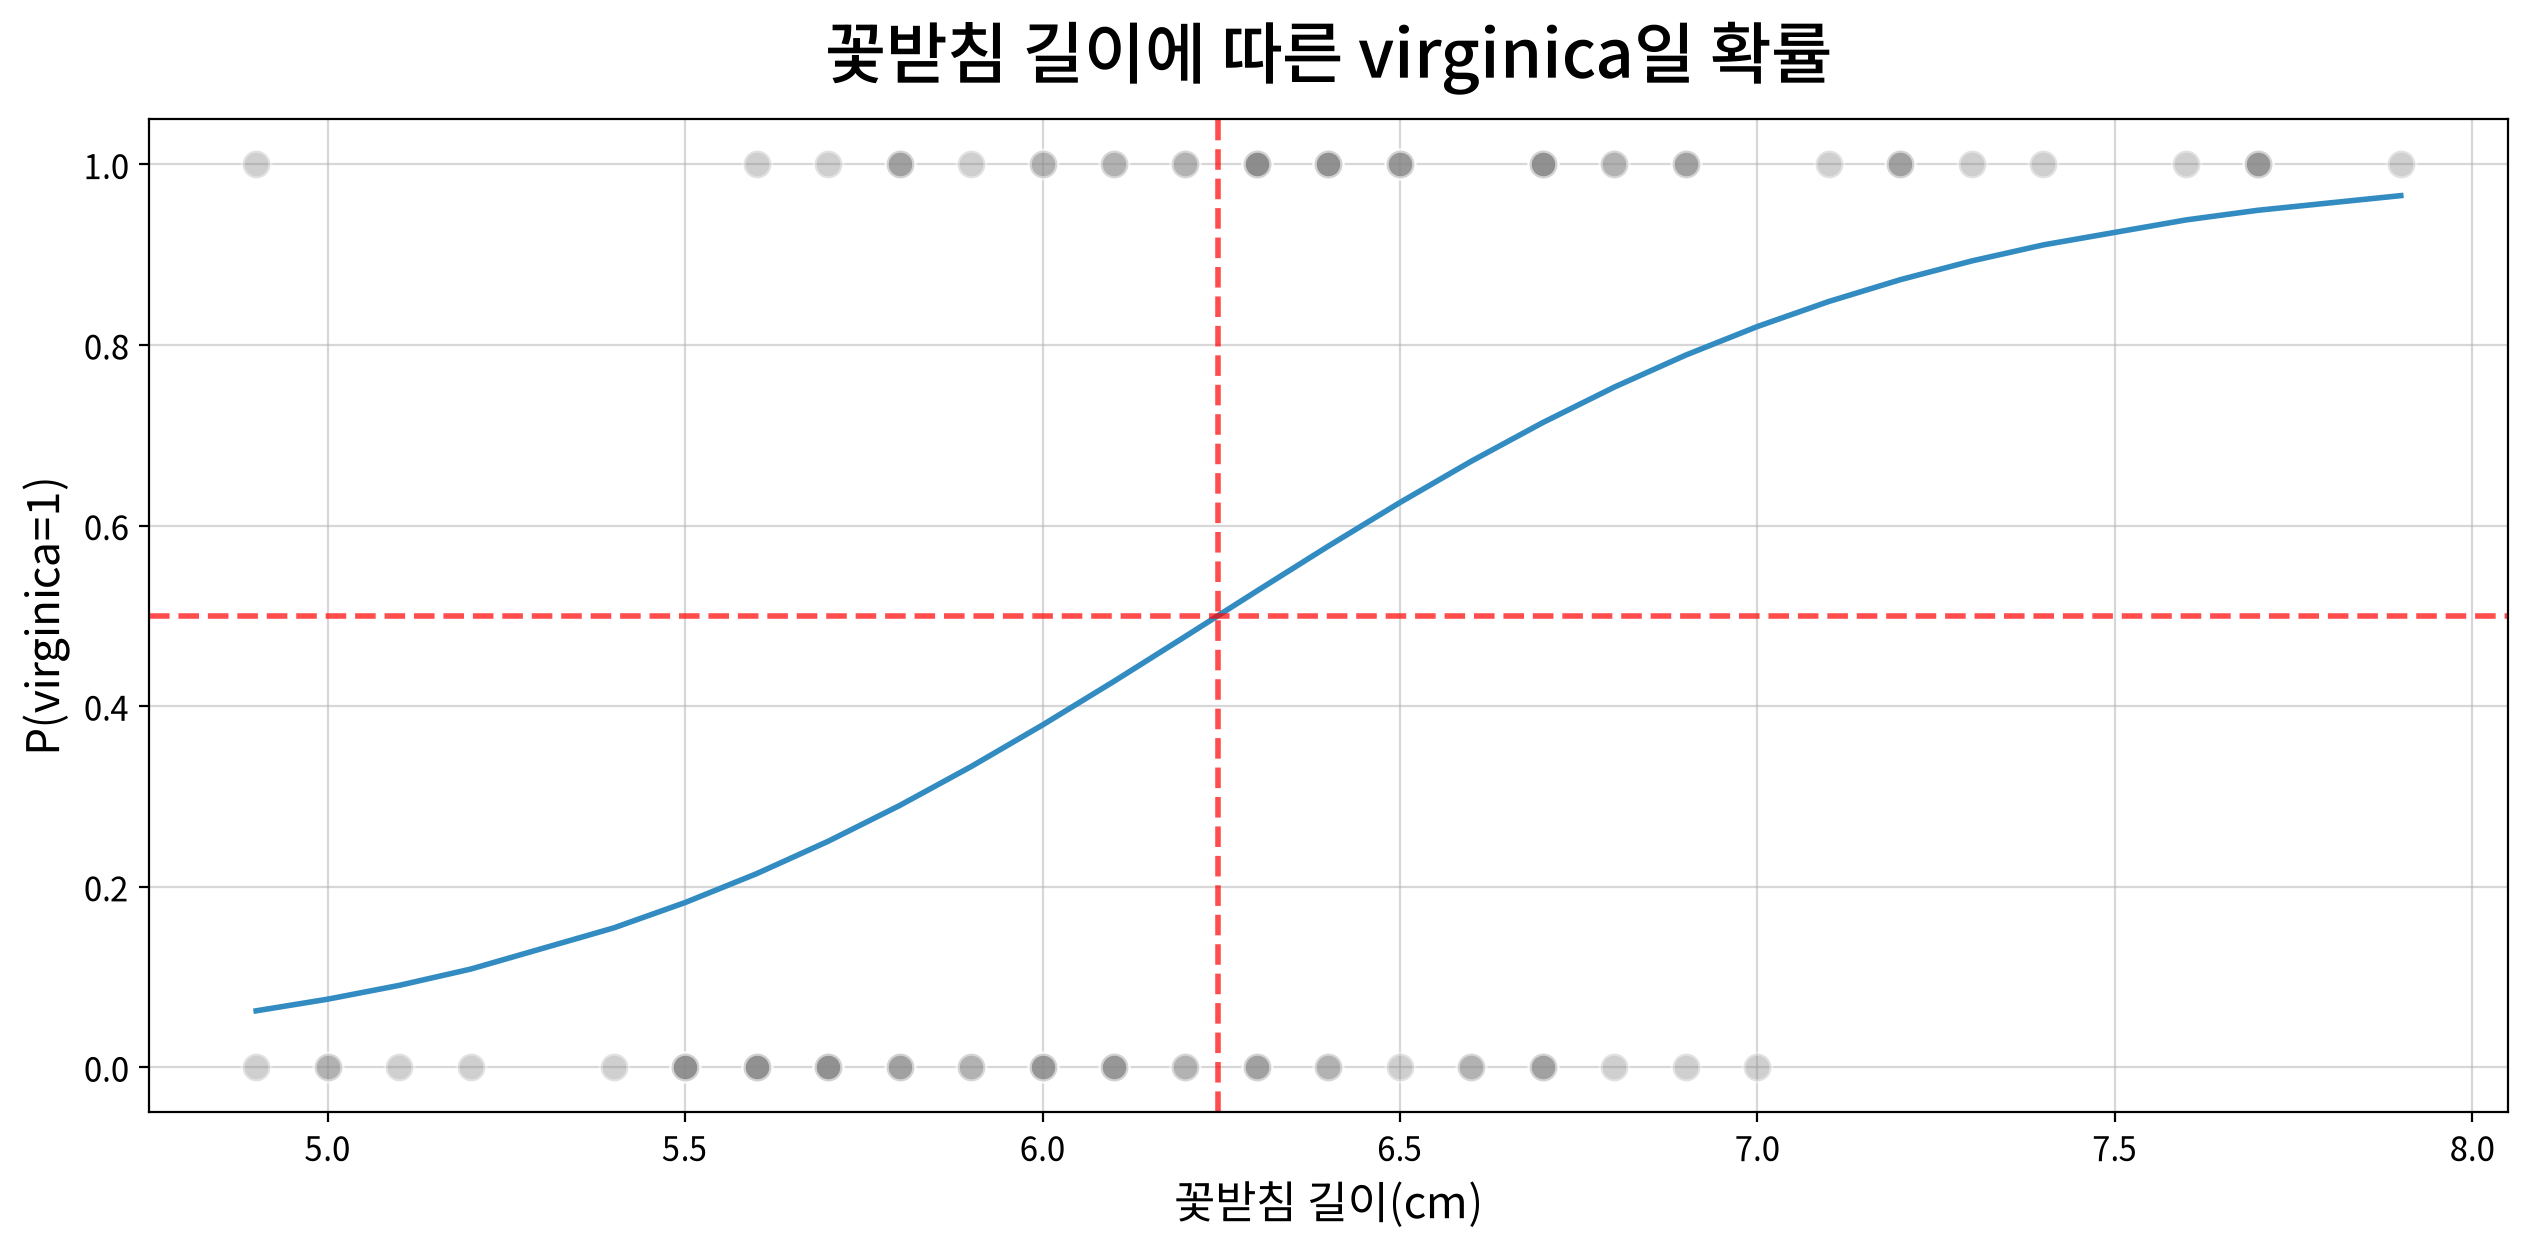

In [20]:
fig , ax = my_plot.init(title='꽃받침 길이에 따른 virginica일 확률', 
                        xlabel='꽃받침 길이(cm)', ylabel='P(virginica=1)')

# 실제 관측지 (0 또는 1)
my_plot.scatterplot(df, x='Sepal_Length', y='Species', 
                    color='#888888', alpha=0.4, ax=ax)

# 모형이 예측한 확률 곡선 (시그모이드)
my_plot.lineplot(new_df, x='Sepal_Length', y='proba', color='#328CC1', ax=ax)

# 임계값(0.5) 기준선과 분류 경계
ax.axhline(y=threshold, color='red', linestyle='--', alpha=0.7)
ax.axvline(x=boundary, color='red', linestyle='--', alpha=0.7)

my_plot.show()

# 1-2 로지스틱 회귀 모듈화 

## #01. 준비작업 

### 1. 라이브러리 참조 

In [21]:
# 라이브러리 기본 참조 
from jussam import load_data
from helpers import *

### 2. 데이터 가져오기 

In [22]:
origin = load_data('iris_bin')
origin.head()

📚 아이리스 데이터셋을 이진분류 예제용으로 종속변수의 종류를 2개로 변경한 데이터 (Kaggle의 데이터셋을 직접 수정함)

    field         description
--  ------------  ----------------------------
 0  Sepal_Length  꽃받침 길이
 1  Sepal_Width   꽃받침 너비
 2  Petal_Length  꽃잎 길이
 3  Petal_Width   꽃잎 너비
 4  Species       품종 (versicolor, virginica)



,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species
0,7.000,3.200,4.700,1.400,versicolor
1,6.400,3.200,4.500,1.500,versicolor
2,6.900,3.100,4.900,1.500,versicolor
3,5.500,2.300,4.000,1.300,versicolor
4,6.500,2.800,4.600,1.500,versicolor


### 3. 데이터 전처리 

In [23]:
df = origin[['Sepal_Length', 'Species']]
df = my_prep.labeling(df, columns=['Species'])
df.head()

Species (1종) : versicolor=0
Species (2종) : versicolor=0, virginica=1


,Sepal_Length,Species
0,7.000,0
1,6.400,0
2,6.900,0
3,5.500,0
4,6.500,0


## #02. 모듈화 기능 확인 

### 1. 로지스틱 모델 적합 

In [24]:
fit = my_logit.fit_model(df, y='Species', summary=True) 

                           Logit Regression Results                           
Dep. Variable:                Species   No. Observations:                  100
Model:                          Logit   Df Residuals:                       98
Method:                           MLE   Df Model:                            1
Date:                Thu, 30 Jul 2026   Pseudo R-squ.:                  0.2026
Time:                        12:47:52   Log-Likelihood:                -55.273
converged:                       True   LL-Null:                       -69.315
Covariance Type:            nonrobust   LLR p-value:                 1.162e-07
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -12.5708      2.907     -4.325      0.000     -18.268      -6.873
Sepal_Length     2.0129      0.465      4.325      0.000       1.101       2.925


### 2. 예측값 생성 

In [25]:
pred = my_logit.predict(fit, df[['Sepal_Length']])

new_df = df.copy()
new_df[['proba', 'pred']] = pred

new_df.head()

,Sepal_Length,Species,proba,pred
0,7.000,0,0.820,1
1,6.400,0,0.577,1
2,6.900,0,0.789,1
3,5.500,0,0.182,0
4,6.500,0,0.626,1


### 3. 시그모이드 곡선 시각화 
plot_sigmoid()는 관측치 산점도, S자 곡선, 임계값, 분류 경계를 한번에 그려준다. 

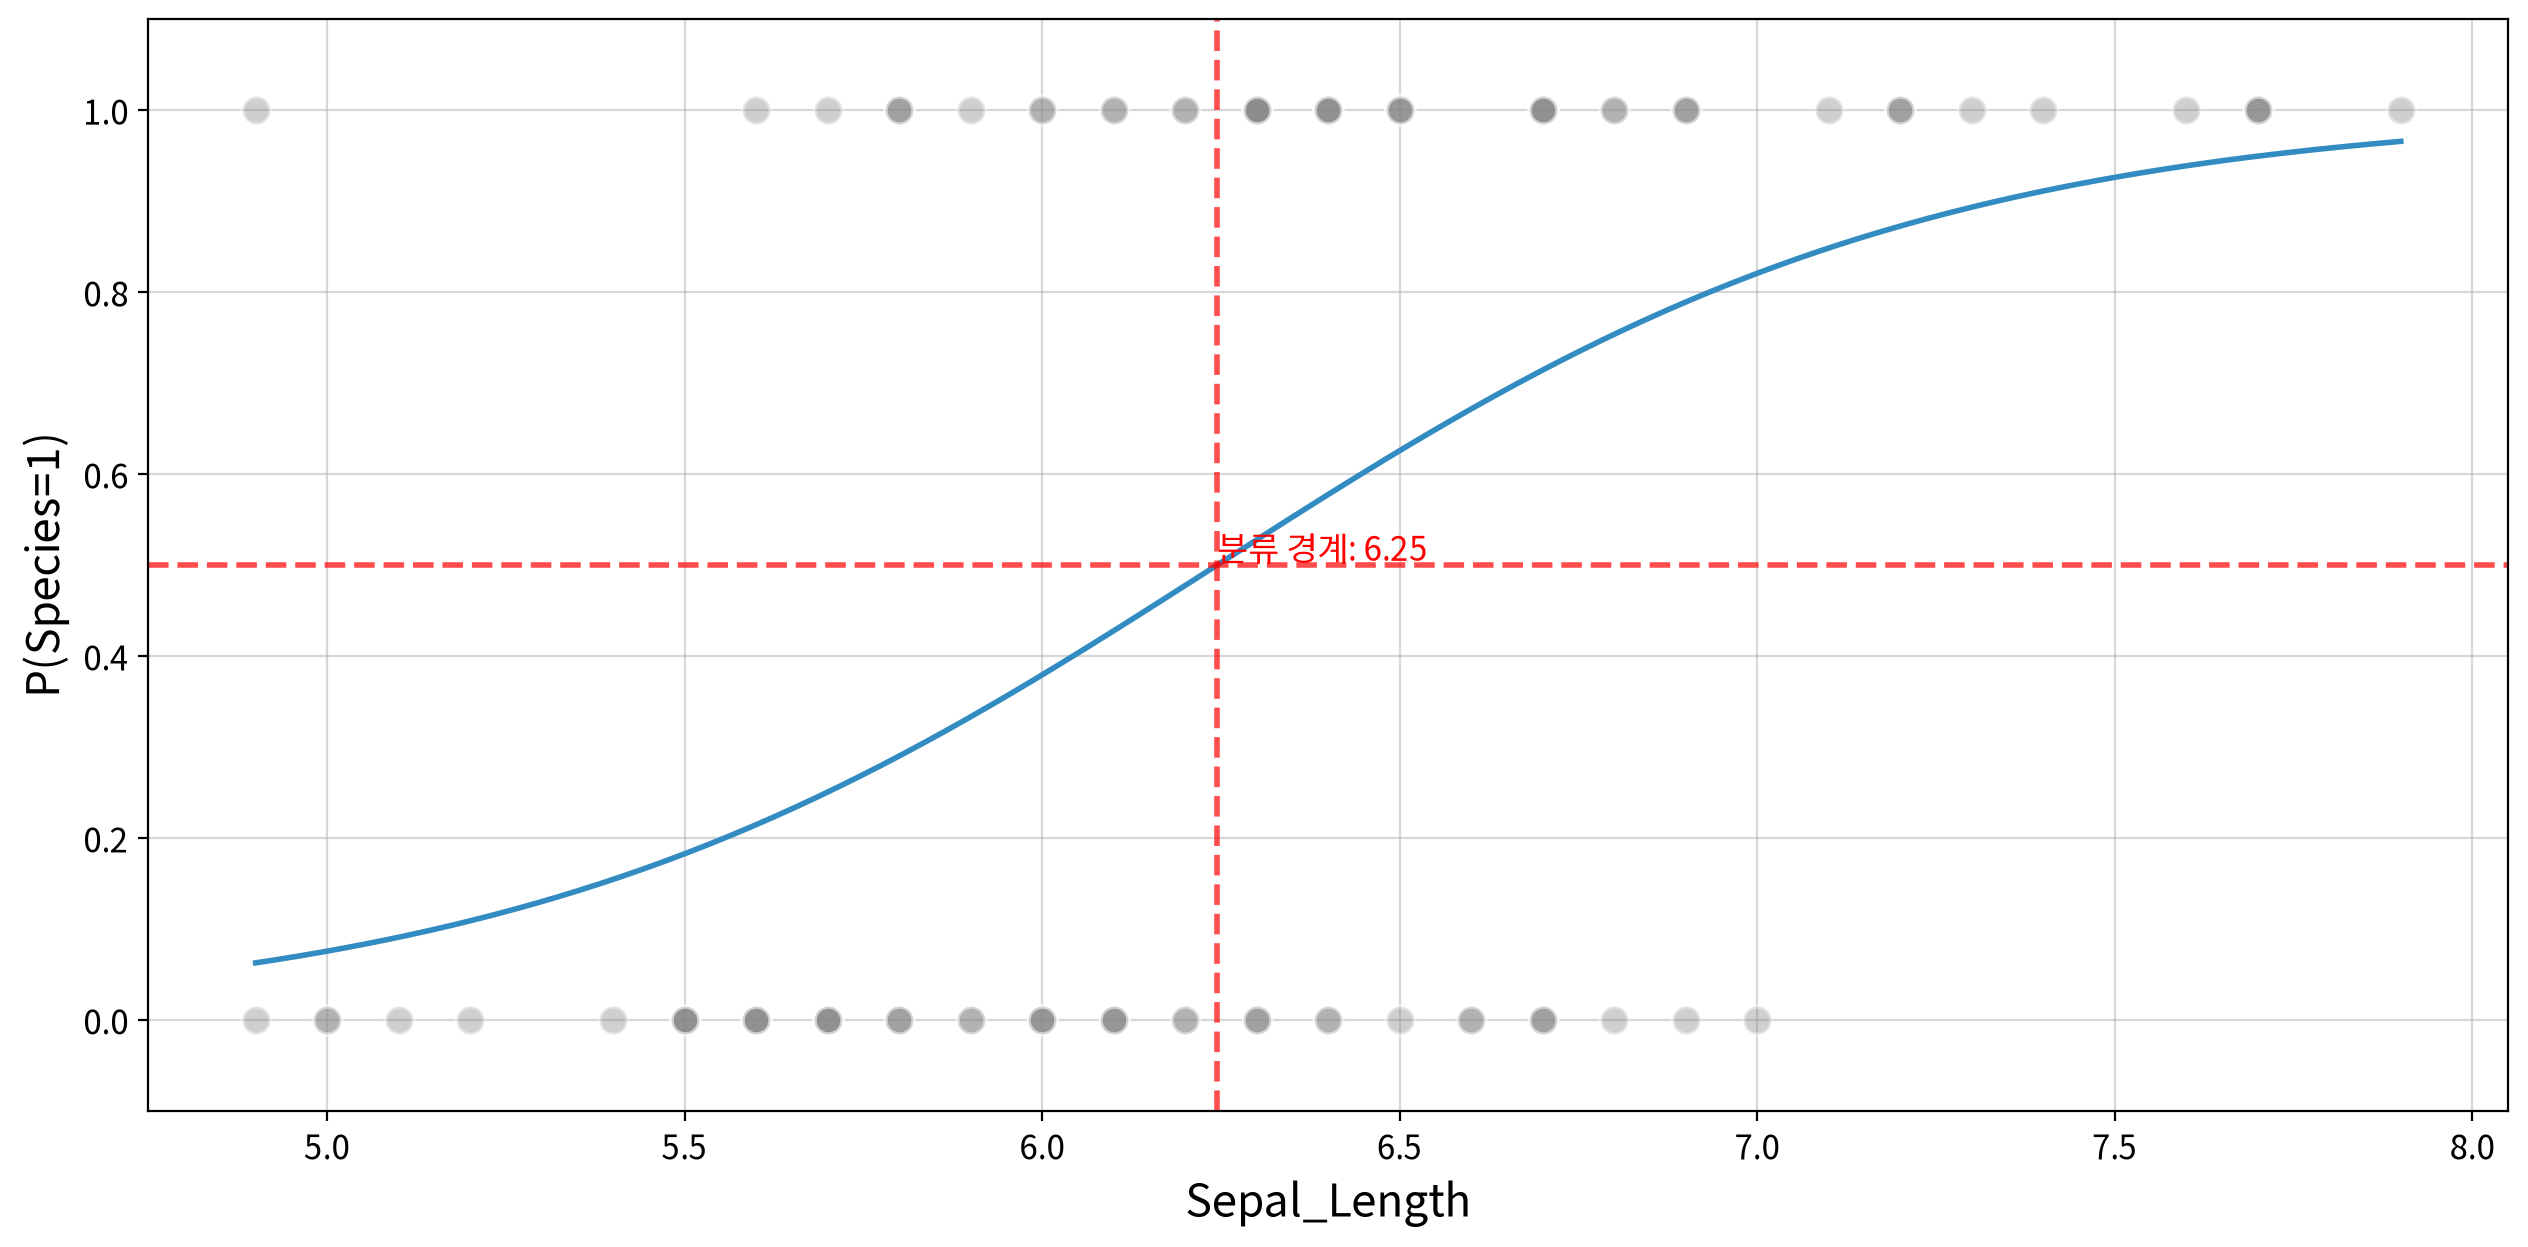

In [26]:
my_logit.plot_sigmoid(fit, new_df, x='Sepal_Length')

## # 연습문제 

In [27]:
from jussam import load_data
from helpers import *

In [28]:
origin = load_data('pitcher_wins')
origin.head()

📚 야구선수 신맵돌의 실점과 승리 여부를 기록한 데이터


,실점,승리여부
0,4,0
1,1,1
2,3,0
3,3,1
4,2,0


In [29]:
df = origin[['실점', '승리여부']]
df = my_prep.labeling(df, columns=['승리여부'])
df.head()

승리여부 (1종) : 0=0
승리여부 (2종) : 0=0, 1=1


,실점,승리여부
0,4,0
1,1,1
2,3,0
3,3,1
4,2,0


In [30]:
print(origin['승리여부'].value_counts())

승리여부
0    128
1    112
Name: count, dtype: int64


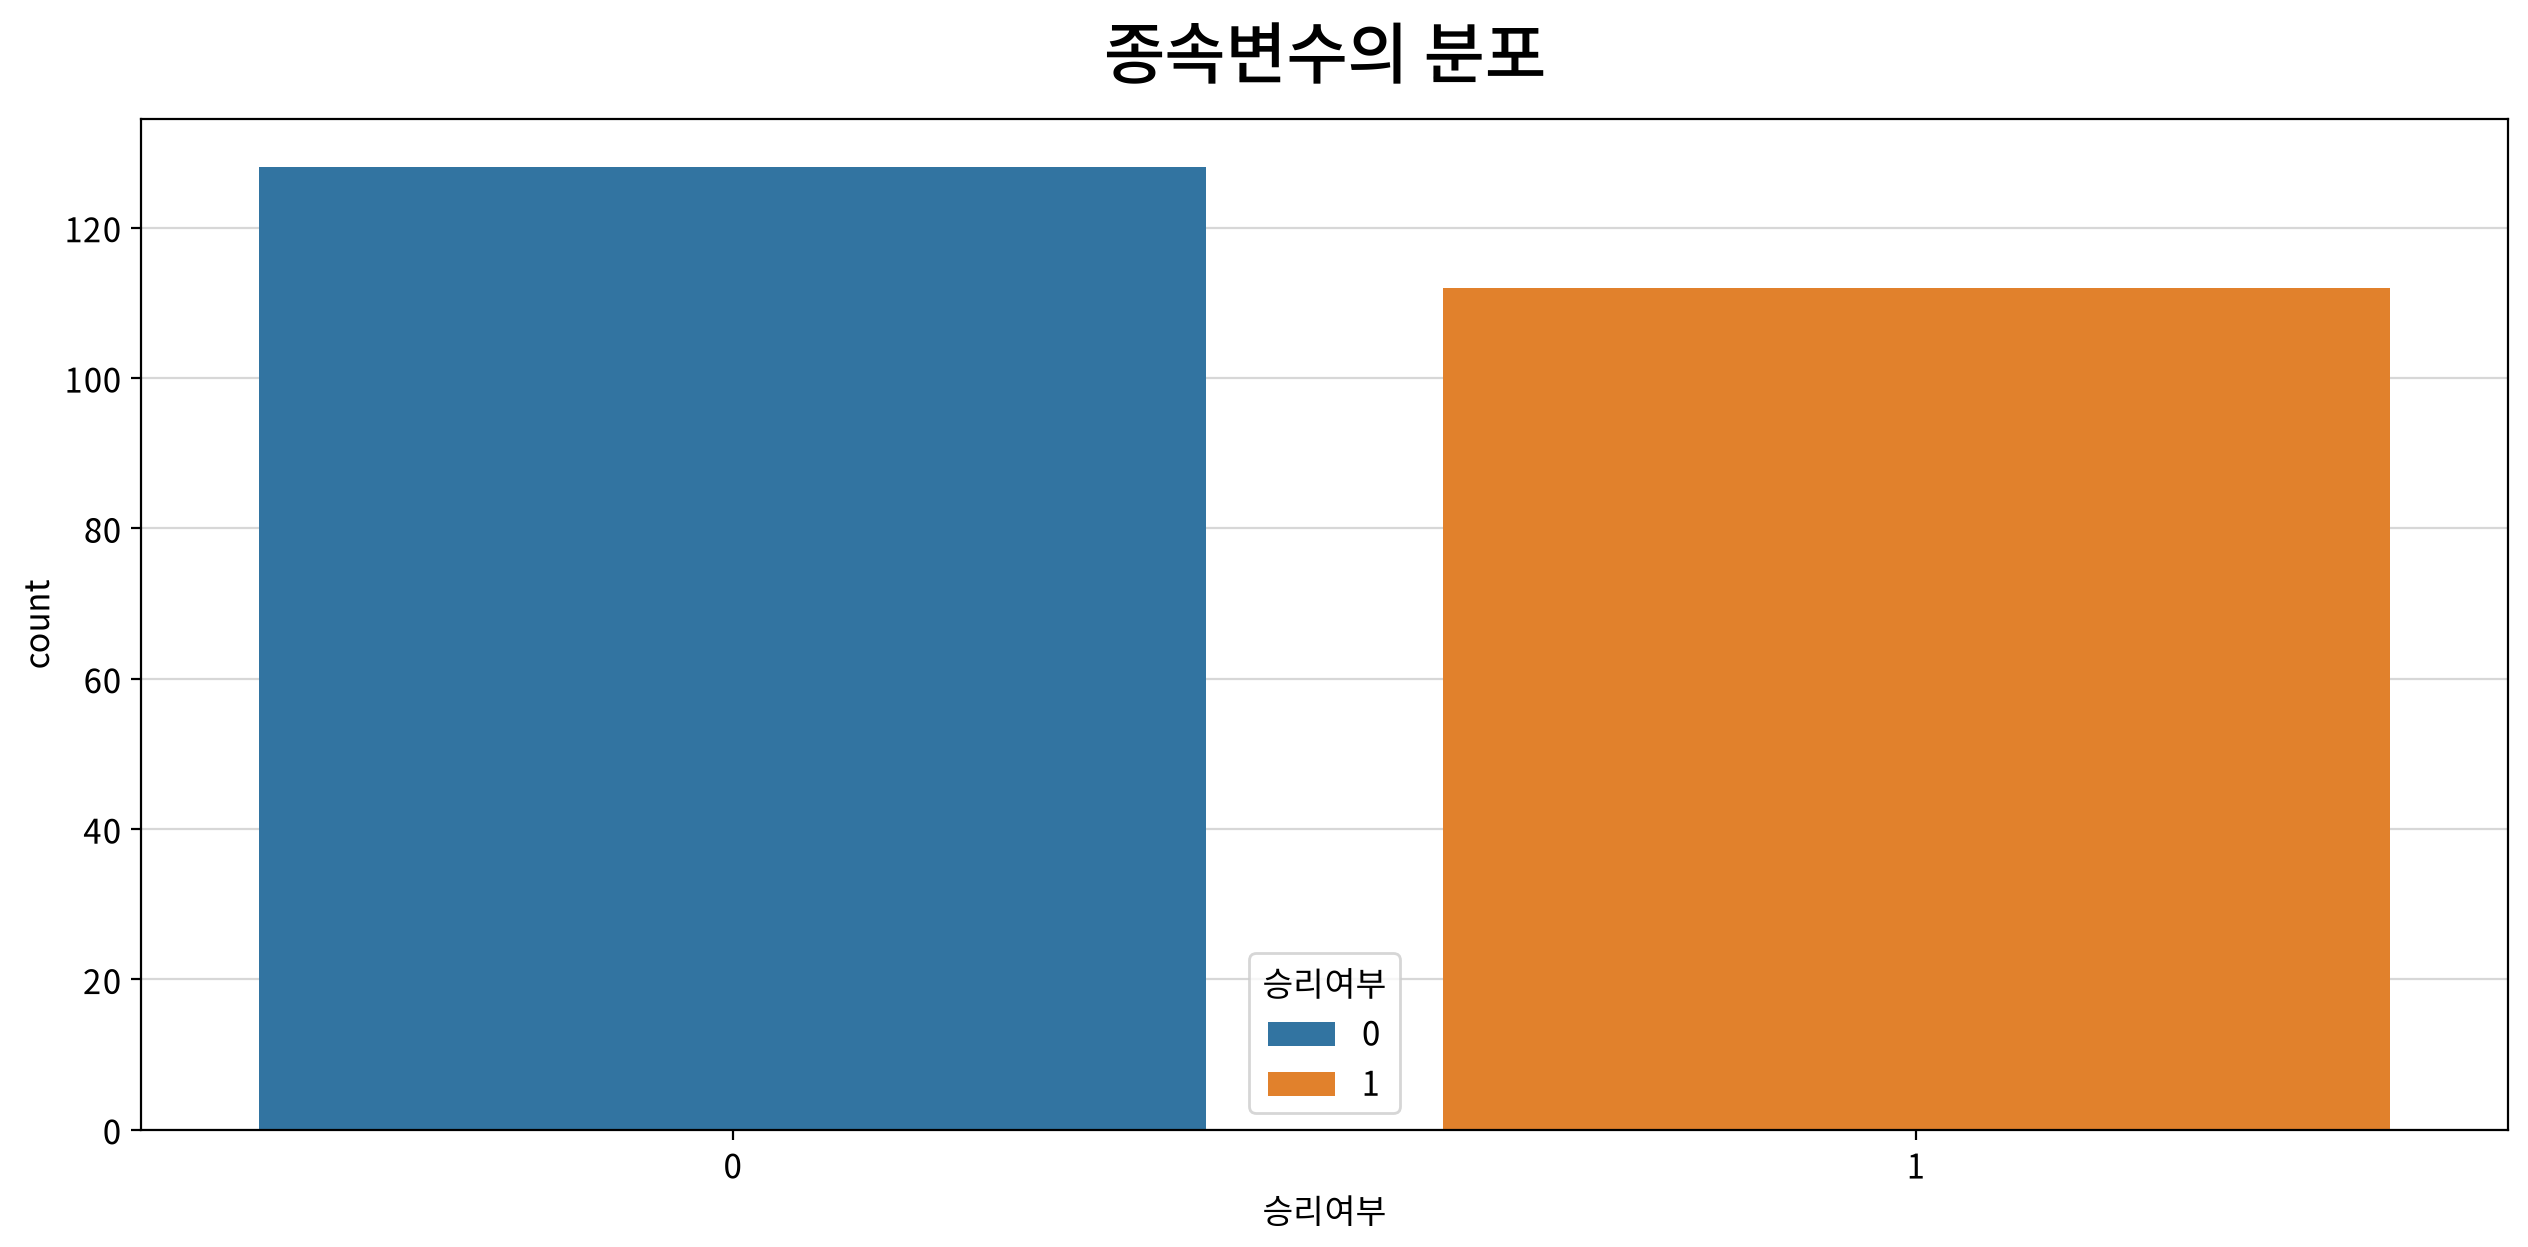

In [31]:
my_plot.countplot(df, x='승리여부', hue='승리여부', 
                  title='종속변수의 분포') 

In [32]:
# 문제 1
# 종속변수 승리여부의 두 범주(0/1)중 
# 관측치(경기 수)가 더 많은 값은 무엇이고, 그 경기 수는 몇경기 인가?

# 0(패배) 128 경기 

In [33]:
print(origin.groupby('승리여부')['실점'].mean())

승리여부
0   3.766
1   2.357
Name: 실점, dtype: float64


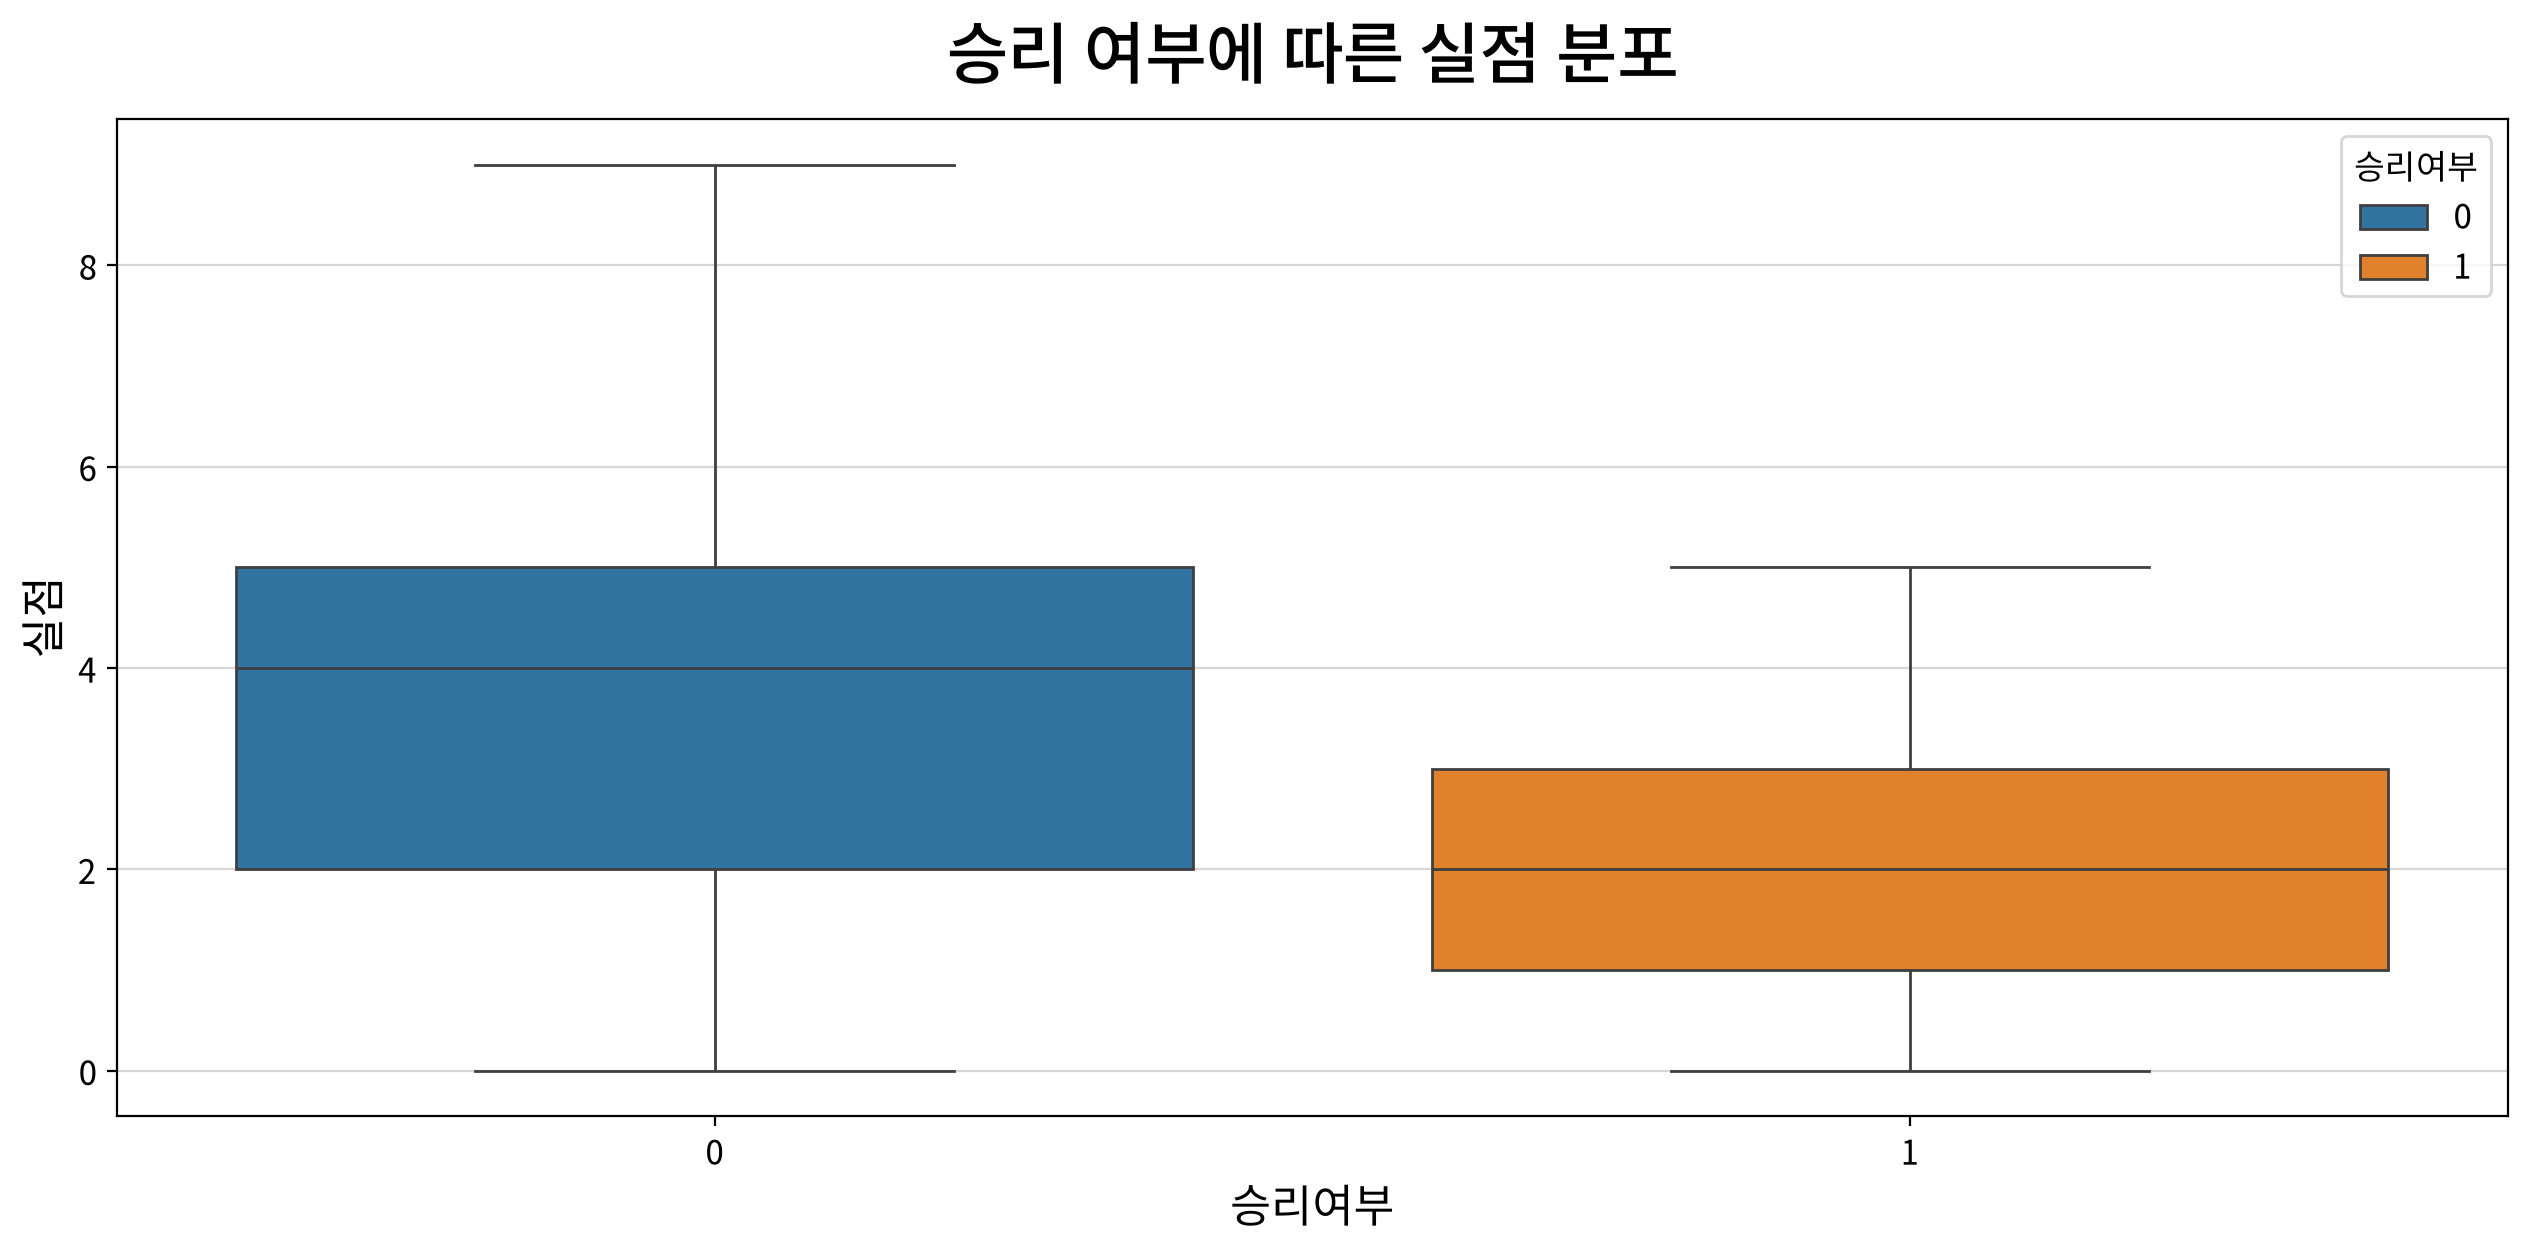

In [34]:
my_plot.boxplot(origin, x='승리여부', y='실점', hue='승리여부', 
                title='승리 여부에 따른 실점 분포', xlabel='승리여부', 
                ylabel='실점')

In [35]:
# 문제 2 
#  승리한 경기(1)와 그렇지 못한 경기(0) 중
# 평균 실점이 더 낮은 쪽은 어느 범주인가?

# 1(승리한 경기)


In [36]:
ols_fit = my_ols.auto_ols(df, y='승리여부', report=True, test=False)

#### ▶︎ 모형 적합도

,종속변수,독립변수,B,표준오차,표준오차(HC3),베타,t,t(HC3),유의확률,유의확률(HC3),공차,VIF
0,승리여부,실점,-0.117,0.017,0.014,-0.406,-6.852,-8.531,0.000,0.000,1.000,1.000


**Note. n = 240. F(1, 238) = 46.95, p < 0.001, R² = 0.165, Adj.R² = 0.161, Durbin-Watson = 2.14**

승리여부를 종속변수로, 실점(을)를 독립변수로한 단순선형회귀분석 결과, 모형은 통계적으로 유의하였다.

> F(1, 238) = 46.95, p < 0.001, R² = 0.165.

즉, 실점는 승리여부의 약 16.48%를 설명하는 것으로 나타났다.

In [37]:
fit = my_logit.fit_model(df, y='승리여부', summary=True) 

                           Logit Regression Results                           
Dep. Variable:                   승리여부   No. Observations:                  240
Model:                          Logit   Df Residuals:                      238
Method:                           MLE   Df Model:                            1
Date:                Thu, 30 Jul 2026   Pseudo R-squ.:                  0.1305
Time:                        12:47:53   Log-Likelihood:                -144.19
converged:                       True   LL-Null:                       -165.82
Covariance Type:            nonrobust   LLR p-value:                 4.774e-11
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.5699      0.317      4.945      0.000       0.948       2.192
실점            -0.5624      0.096     -5.841      0.000      -0.751      -0.374


In [38]:
# 문제3 
# 적합한 로지스틱 모델에서 독립변수 실점의 회귀계수(coef) 부호는 
# 양수인가, 음수인가 

# 음수 -0.5624

In [39]:
pred = my_logit.predict(fit, df[['실점']])

new_df = df.copy()
new_df[['proba', 'pred']] = pred

new_df.head()

,실점,승리여부,proba,pred
0,4,0,0.336,0
1,1,1,0.733,1
2,3,0,0.471,0
3,3,1,0.471,0
4,2,0,0.609,1


In [40]:
# 문제 4
# 예측 범위(pred)가 승리(1)에서 패배(0)로 바뀌기 시작하는 실점은 몇 점 부터인가?

# 3점 부터 

# 시그모이드 곡선의 분류 경계는 실점 ~~ 2.76점(=-const/coef)이며
# 정수 실점 기준으로는 3점부터 패배로 예측된다. 

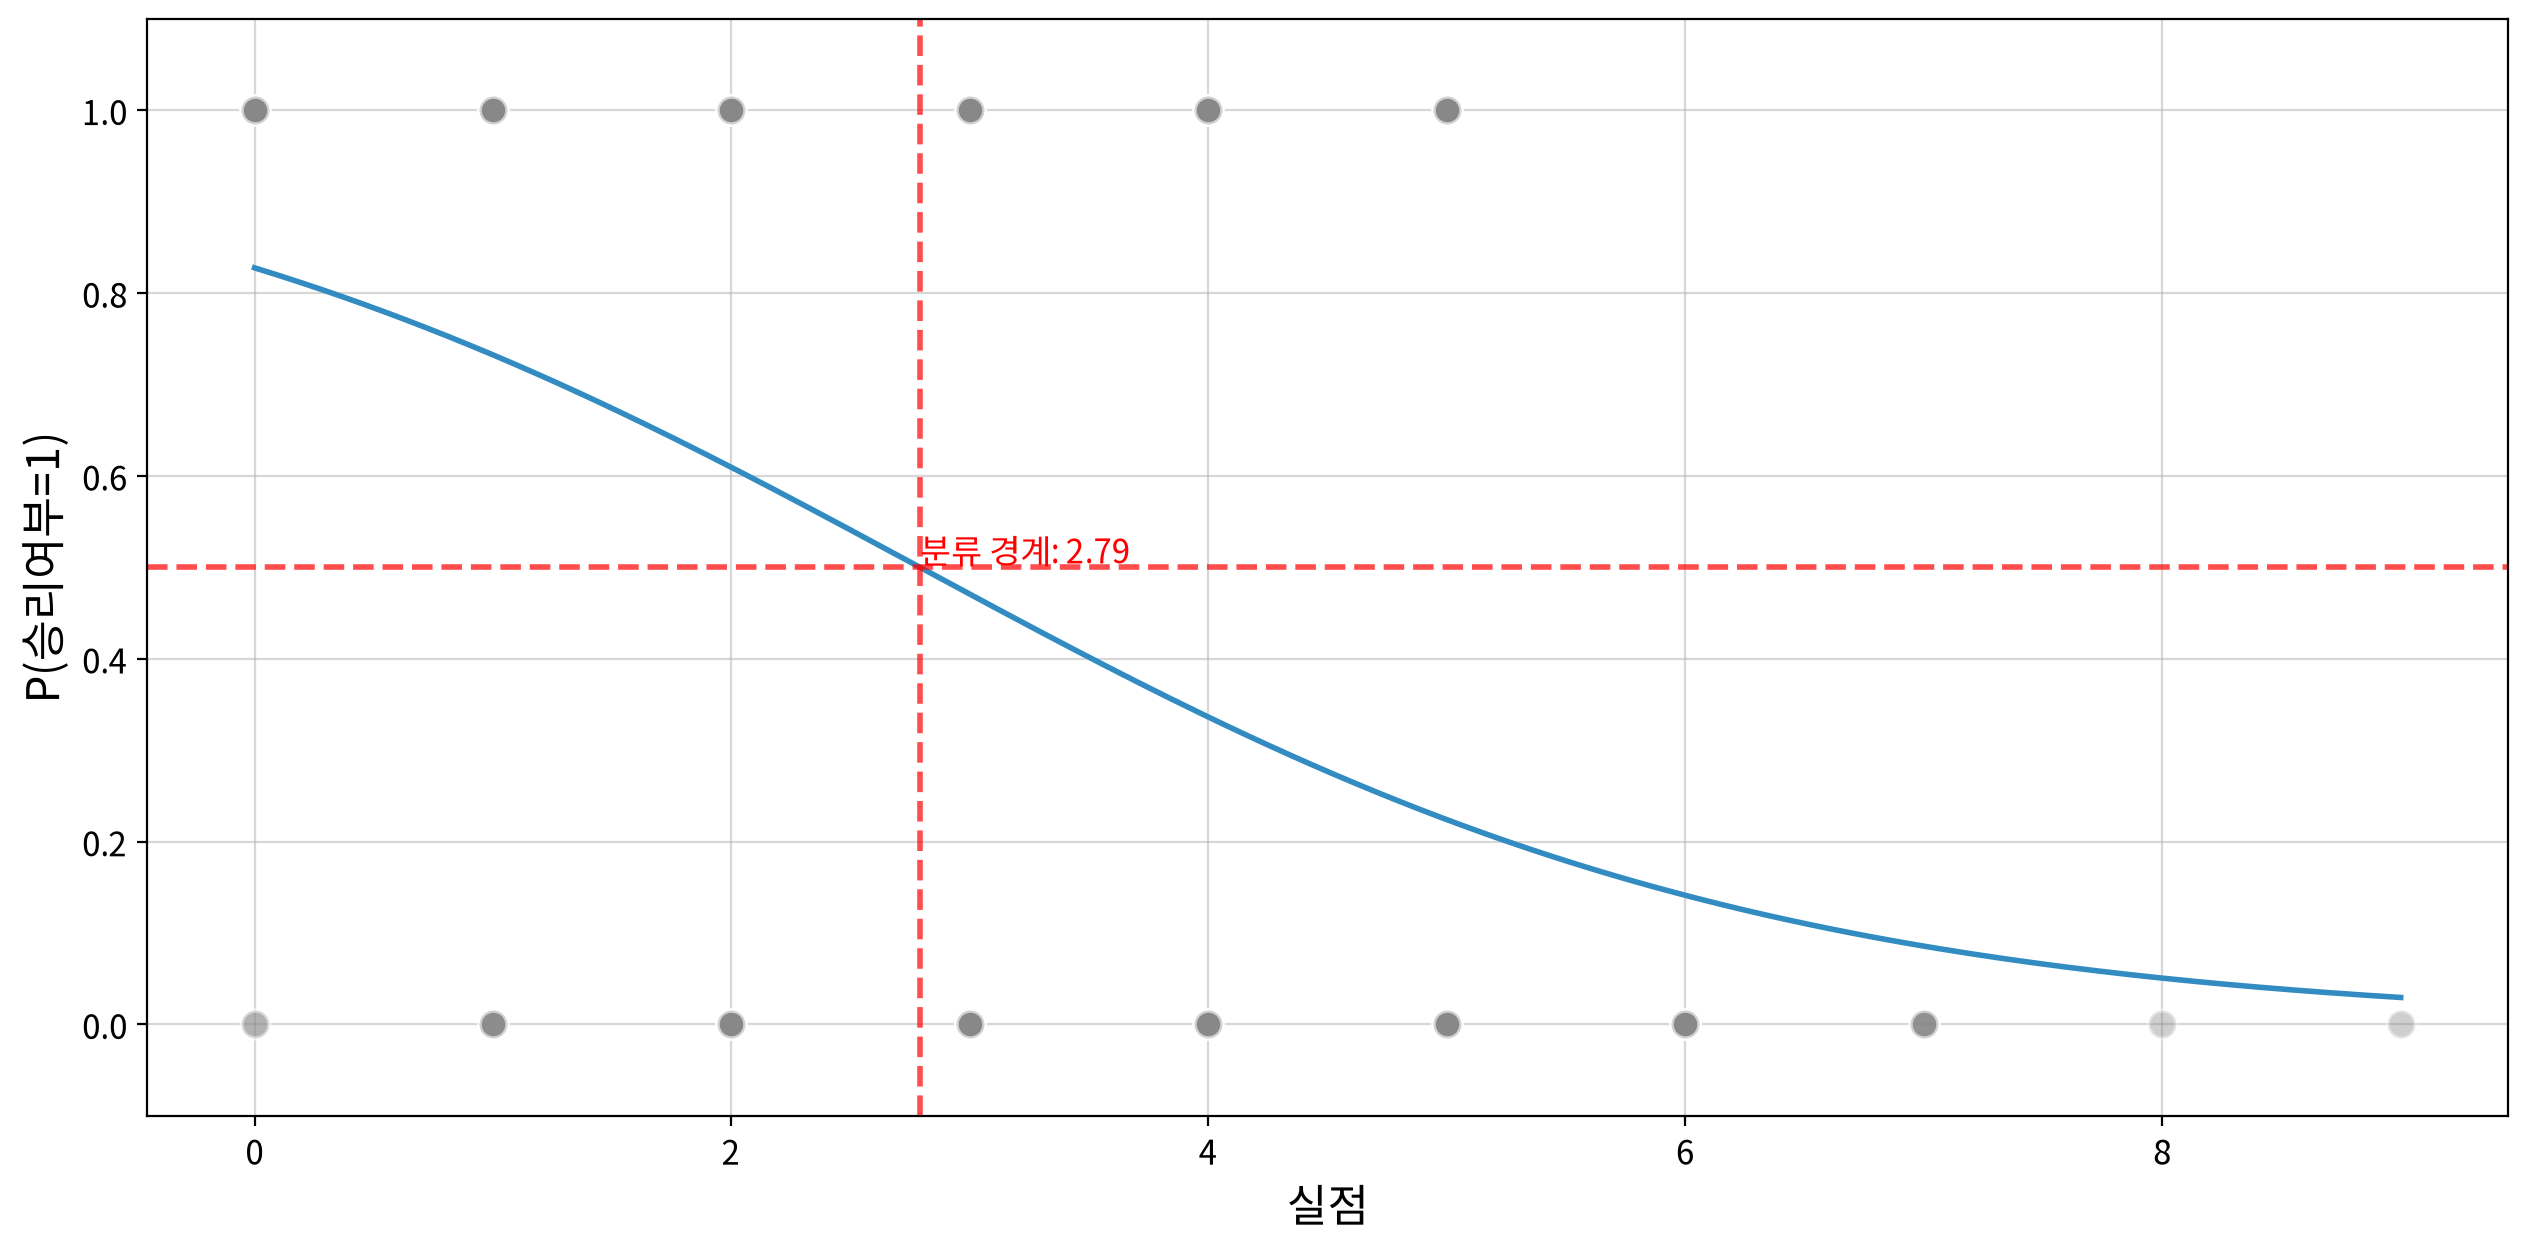

In [41]:
my_logit.plot_sigmoid(fit, new_df, x='실점')